# 📉 Customer Churn Prediction — Telecom Dataset

**Dataset:** [IBM Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
**Records:** ~7,043 customers | **Features:** 21 columns | **Target:** Churn (Yes/No)

---

### 📋 Project Workflow

| Step | Description |
|------|-------------|
| 1 | Setup & Data Loading |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data Cleaning & Preprocessing |
| 4 | Feature Engineering |
| 5 | Model Training (Logistic Regression, Random Forest, XGBoost) |
| 6 | Model Evaluation (Accuracy, Recall, ROC-AUC) |
| 7 | Feature Importance |
| 8 | Key Insights & Business Recommendations |

---
> ⚠️ **Before running:** Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle and place it in the same folder as this notebook.


---
## 🔧 Step 1 — Setup & Data Loading
Import all required libraries and load the IBM Telco Customer Churn dataset.


In [1]:
# ── Import Libraries ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
COLORS = {'churn': '#e74c3c', 'stay': '#2ecc71', 'blue': '#3498db', 'orange': '#f39c12'}

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")


Shape  : 7,043 rows × 21 columns
Memory : 7.15 MB


In [3]:

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

print("Columns & Data Types:")
print(df.dtypes)


Columns & Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:

df.describe(include='all').round(2)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.00,7043,7043,7043.00,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.16,NaN,NaN,32.37,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.37,NaN,NaN,24.56,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.00,NaN,NaN,9.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.00,NaN,NaN,29.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.00,NaN,NaN,55.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


---
## 📊 Step 2 — Exploratory Data Analysis (EDA)
Understand churn patterns through visualizations: overall churn rate, demographics, service usage, contract type, and billing behavior.


In [6]:
# ── Target Variable — Churn Distribution ─────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"  Stayed  (No)  : {churn_counts['No']:>5,}  ({churn_pct['No']:.2f}%)")
print(f"  Churned (Yes) : {churn_counts['Yes']:>5,}  ({churn_pct['Yes']:.2f}%)")
print()
print(f"⚠️  Churn rate: {churn_pct['Yes']:.2f}% — mild class imbalance")


Churn Distribution:
  Stayed  (No)  : 5,174  (73.46%)
  Churned (Yes) : 1,869  (26.54%)

⚠️  Churn rate: 26.54% — mild class imbalance


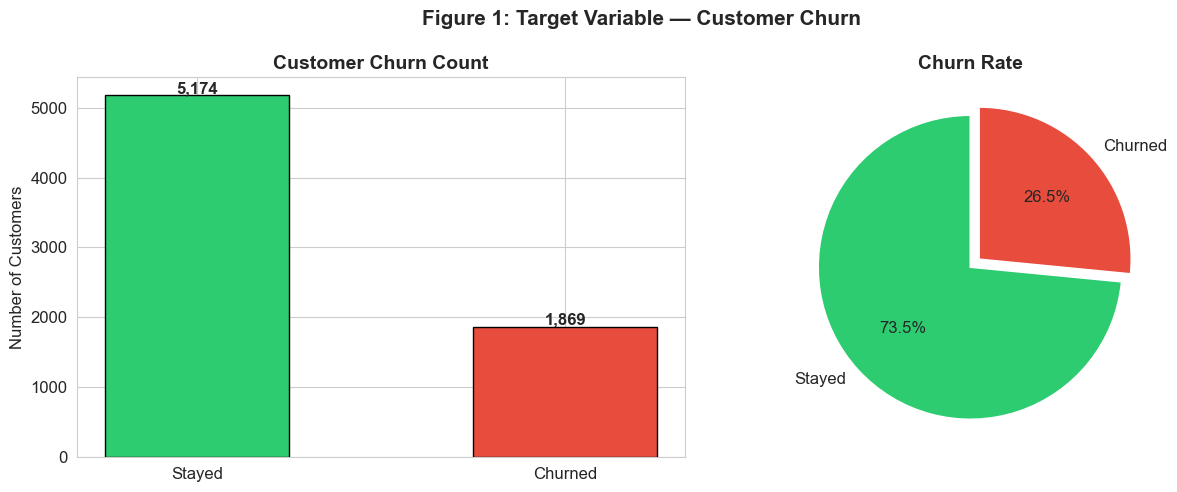

In [7]:
# ── Churn Distribution — Bar & Pie Charts ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(['Stayed', 'Churned'], churn_counts.values,
                    color=[COLORS['stay'], COLORS['churn']],
                    edgecolor='black', width=0.5)
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, v in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 30,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Stayed', 'Churned'],
            autopct='%1.1f%%',
            colors=[COLORS['stay'], COLORS['churn']],
            startangle=90, explode=(0, 0.08),
            textprops={'fontsize': 12})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Figure 1: Target Variable — Customer Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


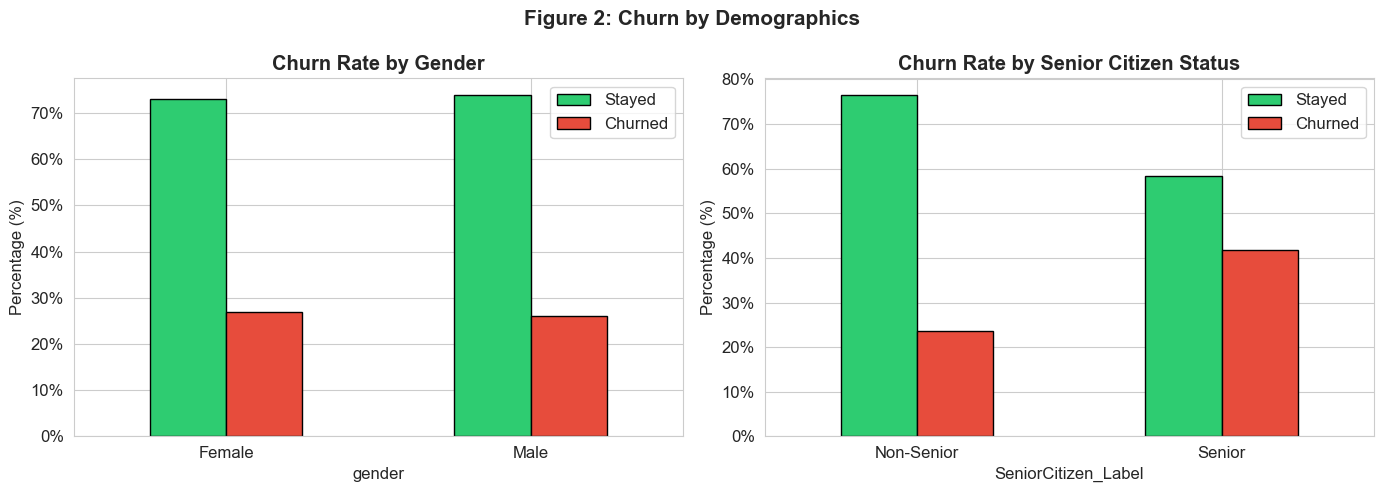

In [8]:
# ── Churn by Gender & Senior Citizen ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack() * 100
gender_churn.plot(kind='bar', ax=axes[0], color=[COLORS['stay'], COLORS['churn']],
                  edgecolor='black', rot=0)
axes[0].set_title('Churn Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Stayed', 'Churned'])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Senior Citizen
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})
senior_churn = df.groupby('SeniorCitizen_Label')['Churn'].value_counts(normalize=True).unstack() * 100
senior_churn.plot(kind='bar', ax=axes[1], color=[COLORS['stay'], COLORS['churn']],
                  edgecolor='black', rot=0)
axes[1].set_title('Churn Rate by Senior Citizen Status', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Stayed', 'Churned'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Figure 2: Churn by Demographics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_churn_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


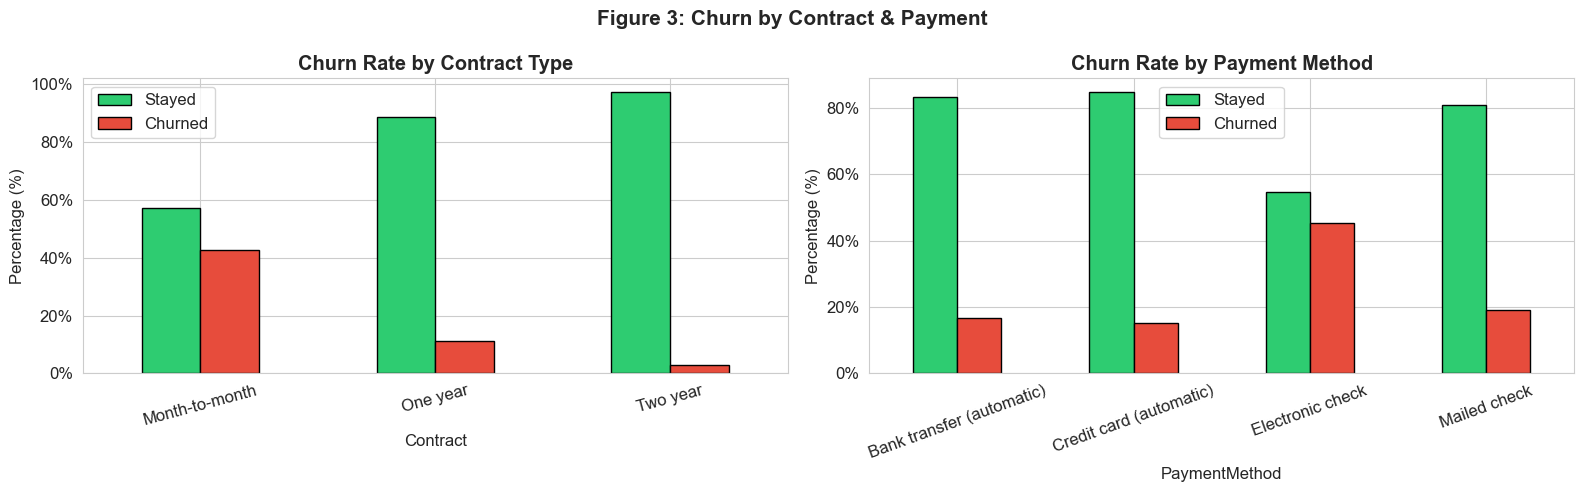

In [9]:
# ── Churn by Contract Type & Payment Method ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Contract
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind='bar', ax=axes[0], color=[COLORS['stay'], COLORS['churn']],
                    edgecolor='black', rot=15)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Stayed', 'Churned'])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Payment method
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
payment_churn.plot(kind='bar', ax=axes[1], color=[COLORS['stay'], COLORS['churn']],
                   edgecolor='black', rot=20)
axes[1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Stayed', 'Churned'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Figure 3: Churn by Contract & Payment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_contract_payment_churn.png', dpi=150, bbox_inches='tight')
plt.show()


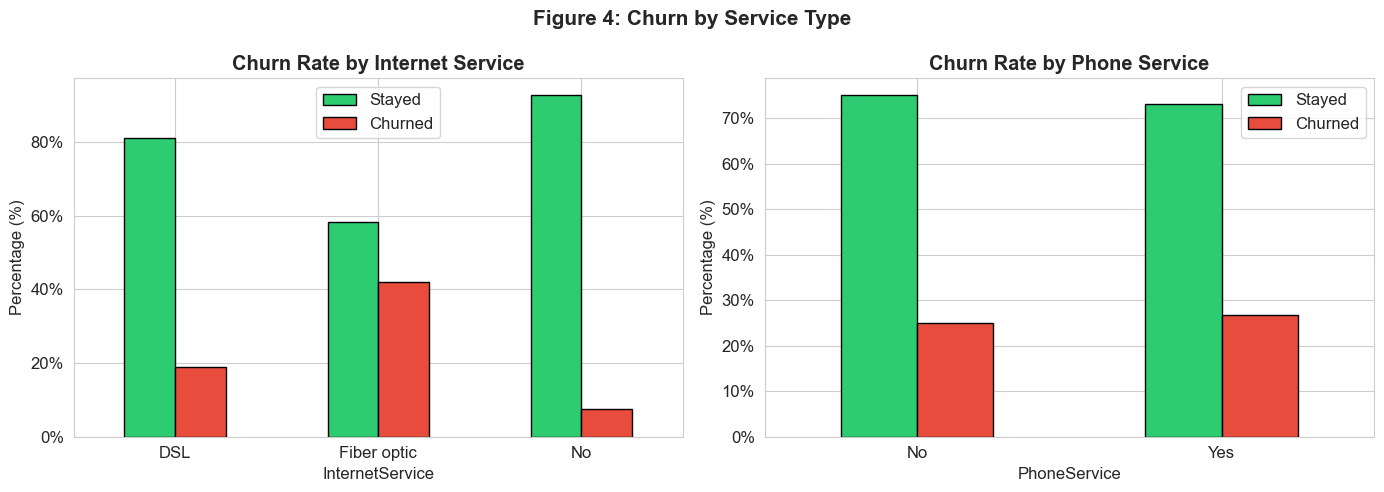

In [10]:
# ── Churn by Internet & Phone Service ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet Service
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
internet_churn.plot(kind='bar', ax=axes[0], color=[COLORS['stay'], COLORS['churn']],
                    edgecolor='black', rot=0)
axes[0].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Stayed', 'Churned'])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Phone Service
phone_churn = df.groupby('PhoneService')['Churn'].value_counts(normalize=True).unstack() * 100
phone_churn.plot(kind='bar', ax=axes[1], color=[COLORS['stay'], COLORS['churn']],
                 edgecolor='black', rot=0)
axes[1].set_title('Churn Rate by Phone Service', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Stayed', 'Churned'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Figure 4: Churn by Service Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_service_churn.png', dpi=150, bbox_inches='tight')
plt.show()


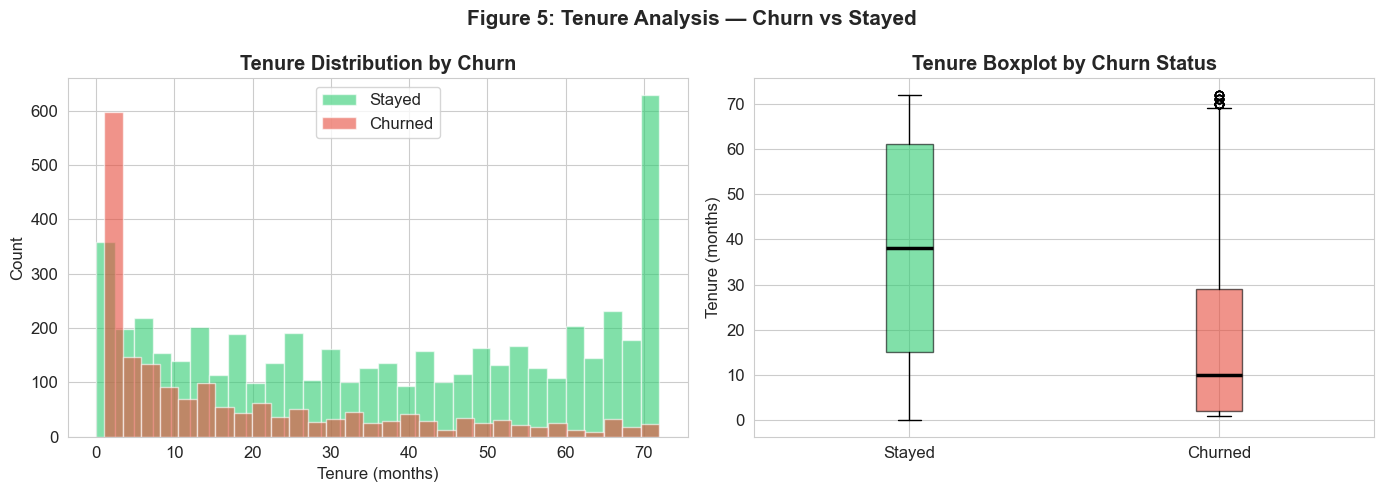

Avg tenure — Stayed : 37.6 months
Avg tenure — Churned: 18.0 months


In [11]:
# ── Tenure Distribution by Churn ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for churn_val, color, label in [('No', COLORS['stay'], 'Stayed'), ('Yes', COLORS['churn'], 'Churned')]:
    axes[0].hist(df[df['Churn'] == churn_val]['tenure'],
                 bins=30, alpha=0.6, color=color, label=label)
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
data_to_plot = [df[df['Churn']=='No']['tenure'], df[df['Churn']=='Yes']['tenure']]
bp = axes[1].boxplot(data_to_plot, labels=['Stayed', 'Churned'],
                     patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2.5))
bp['boxes'][0].set_facecolor(COLORS['stay'])
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(COLORS['churn'])
bp['boxes'][1].set_alpha(0.6)
axes[1].set_title('Tenure Boxplot by Churn Status', fontweight='bold')
axes[1].set_ylabel('Tenure (months)')

plt.suptitle('Figure 5: Tenure Analysis — Churn vs Stayed', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg tenure — Stayed : {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"Avg tenure — Churned: {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")


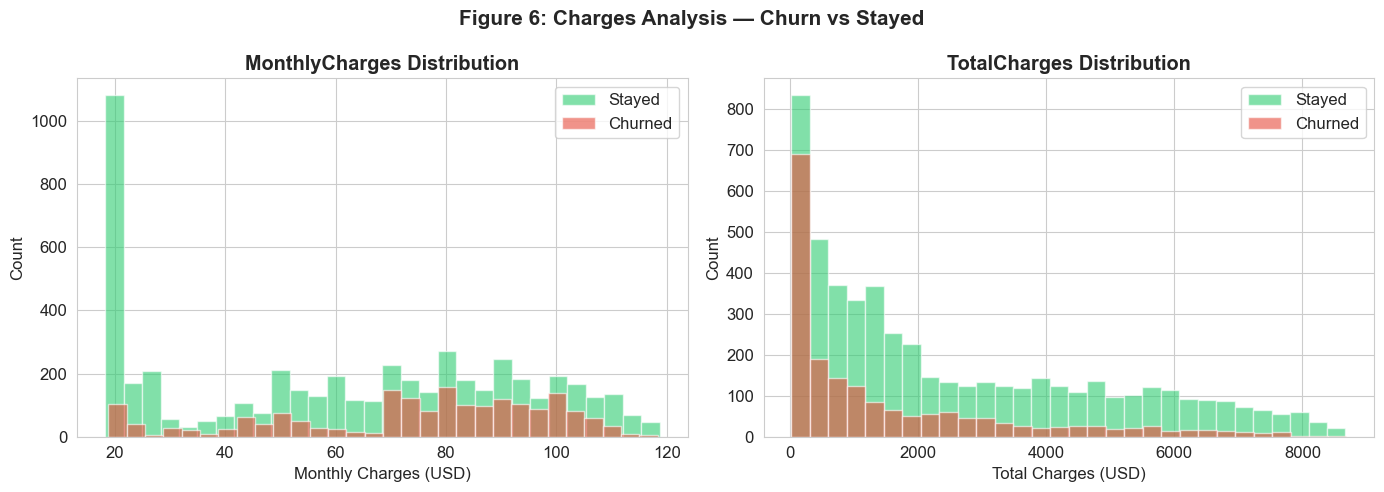

In [12]:
# ── Monthly Charges & Total Charges by Churn ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

numeric_cols = ['MonthlyCharges', 'TotalCharges']
plot_labels  = ['Monthly Charges (USD)', 'Total Charges (USD)']

for ax, col, label in zip(axes, numeric_cols, plot_labels):
    for churn_val, color, lbl in [('No', COLORS['stay'], 'Stayed'), ('Yes', COLORS['churn'], 'Churned')]:
        ax.hist(pd.to_numeric(df[df['Churn']==churn_val][col], errors='coerce').dropna(),
                bins=30, alpha=0.6, color=color, label=lbl)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Figure 6: Charges Analysis — Churn vs Stayed', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


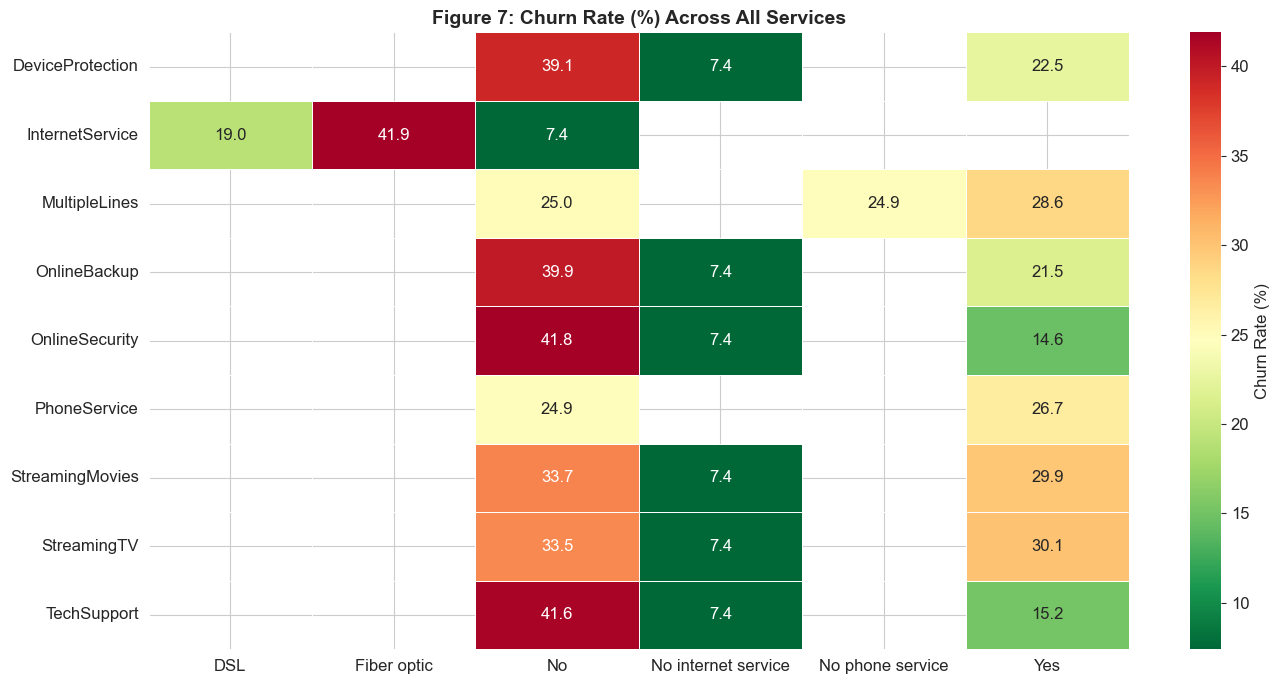

In [13]:
# ── Churn Rate Across Multiple Services (Heatmap) ────────────
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

churn_by_service = pd.DataFrame()
for col in service_cols:
    ct = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()
    ct.columns = ['Category', 'ChurnRate']
    ct['Feature'] = col
    churn_by_service = pd.concat([churn_by_service, ct], ignore_index=True)

pivot = churn_by_service.pivot(index='Feature', columns='Category', values='ChurnRate').round(1)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Figure 7: Churn Rate (%) Across All Services', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.savefig('fig7_service_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


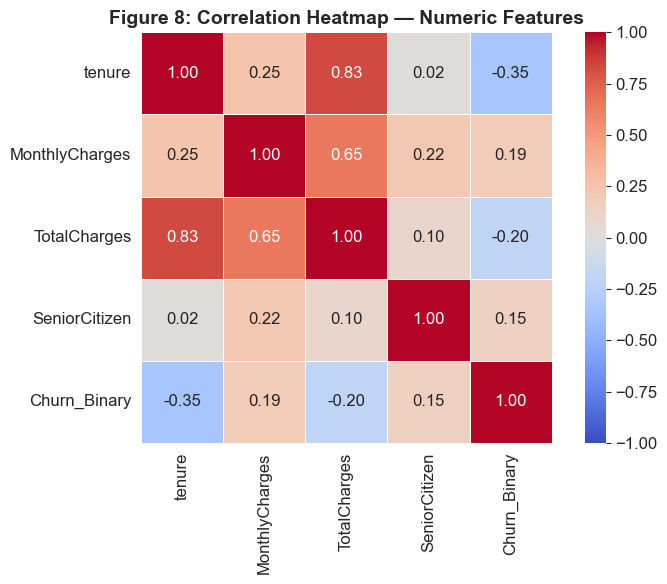

In [14]:
# ── Correlation Heatmap (Numeric Features) ───────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges',
                  'SeniorCitizen', 'Churn_Binary']].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr().round(2), annot=True, cmap='coolwarm',
            fmt='.2f', square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Figure 8: Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🧹 Step 3 — Data Cleaning & Preprocessing
Handle missing values, fix data types, and prepare the dataset for modeling.


In [15]:
# ── Check Missing Values ─────────────────────────────────────
print("Missing Values Before Cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# TotalCharges has spaces that become NaN after pd.to_numeric
missing_total = df['TotalCharges'].isnull().sum()
print(f"TotalCharges null count : {missing_total}")
print(f"These are likely new customers (tenure=0)")
print()
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())


Missing Values Before Cleaning:
TotalCharges    11
dtype: int64

TotalCharges null count : 11
These are likely new customers (tenure=0)

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN


In [16]:
# ── Fix TotalCharges — Fill with MonthlyCharges for tenure=0 ─
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

print(f"Missing TotalCharges after fix: {df['TotalCharges'].isnull().sum()}")
print("✅ TotalCharges cleaned.")


Missing TotalCharges after fix: 0
✅ TotalCharges cleaned.


In [17]:
# ── Drop Unnecessary Columns ─────────────────────────────────
# customerID: unique identifier — not useful for modeling
# SeniorCitizen_Label: duplicate of SeniorCitizen
# Churn_Binary: we'll recreate this after encoding

df.drop(columns=['customerID', 'SeniorCitizen_Label', 'Churn_Binary'], inplace=True, errors='ignore')

print(f"Columns after drop: {df.shape[1]}")
print(list(df.columns))


Columns after drop: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [18]:
# ── Encode Target Variable ───────────────────────────────────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn encoding:")
print(df['Churn'].value_counts())


Churn encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [19]:
# ── Identify Categorical Columns ─────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Churn').tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print()
print(f"Numerical columns  ({len(num_cols)}): {num_cols}")


Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [20]:
# ── Encode Categorical Features (One-Hot Encoding) ───────────
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Total features: {df_encoded.shape[1] - 1}  (excluding target)")
df_encoded.head(3)


Shape after encoding: (7043, 31)
Total features: 30  (excluding target)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


---
## ⚙️ Step 4 — Feature Engineering
Create new meaningful features that could improve model performance.


In [21]:
# ── Tenure Groups ─────────────────────────────────────────────
# Convert continuous tenure into customer lifecycle groups
def tenure_group(tenure):
    if tenure <= 12:   return 'New (0-12m)'
    elif tenure <= 24: return 'Growing (12-24m)'
    elif tenure <= 48: return 'Established (24-48m)'
    else:              return 'Loyal (48m+)'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
tenure_churn = df.groupby('TenureGroup')['Churn'].mean() * 100

print("Churn Rate by Tenure Group:")
print(tenure_churn.sort_values(ascending=False).round(2).to_string())


Churn Rate by Tenure Group:
TenureGroup
New (0-12m)             47.44
Growing (12-24m)        28.71
Established (24-48m)    20.39
Loyal (48m+)             9.51


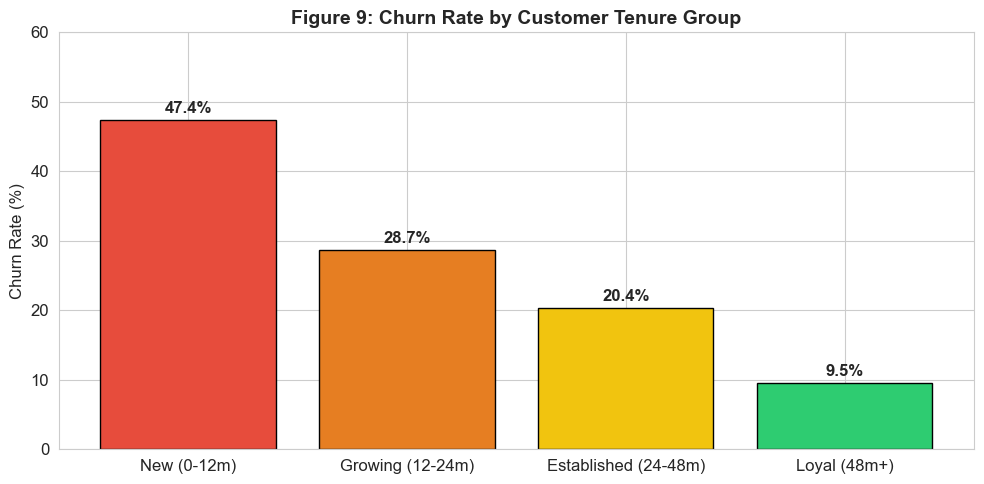

In [22]:
# ── Tenure Group — Churn Bar Chart ───────────────────────────
order = ['New (0-12m)', 'Growing (12-24m)', 'Established (24-48m)', 'Loyal (48m+)']
churn_by_tenure = df.groupby('TenureGroup')['Churn'].mean() * 100
churn_by_tenure = churn_by_tenure.reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(order, churn_by_tenure.values,
              color=[COLORS['churn'], '#e67e22', '#f1c40f', COLORS['stay']],
              edgecolor='black')
ax.set_title('Figure 9: Churn Rate by Customer Tenure Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
for bar, v in zip(bars, churn_by_tenure.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1,
            f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_tenure_group_churn.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# ── Charges per Month (Avg Billing Efficiency) ───────────────
df['AvgChargePerMonth'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

print("AvgChargePerMonth stats by Churn:")
print(df.groupby('Churn')['AvgChargePerMonth'].describe().round(2))


AvgChargePerMonth stats by Churn:
        count   mean    std    min    25%    50%    75%     max
Churn                                                          
0      5174.0  61.27  31.14  13.78  25.35  63.98  87.72  120.75
1      1869.0  74.43  24.96  14.15  57.98  79.31  93.93  121.40


In [24]:
# ── Number of Services Subscribed ────────────────────────────
service_flags = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies']

# Count services that are 'Yes'
df['NumServices'] = df[service_flags].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

print("NumServices distribution:")
print(df.groupby('NumServices')['Churn'].agg(['mean', 'count']).rename(
    columns={'mean': 'ChurnRate', 'count': 'Customers'}).round(3))


NumServices distribution:
             ChurnRate  Customers
NumServices                      
0                0.438         80
1                0.211       1701
2                0.328       1188
3                0.365        965
4                0.313        922
5                0.256        908
6                0.225        676
7                0.124        395
8                0.053        208


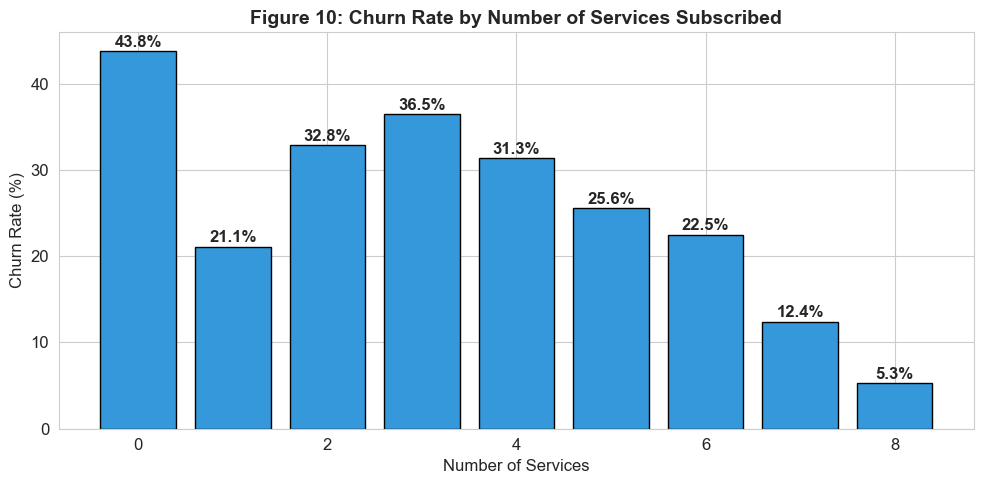

In [25]:
# ── Services vs Churn Rate ───────────────────────────────────
num_svc_churn = df.groupby('NumServices')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(num_svc_churn.index, num_svc_churn.values,
       color=COLORS['blue'], edgecolor='black')
ax.set_title('Figure 10: Churn Rate by Number of Services Subscribed',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Services')
ax.set_ylabel('Churn Rate (%)')
for x, v in zip(num_svc_churn.index, num_svc_churn.values):
    ax.text(x, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_services_churn.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🤖 Step 5 — Model Training
Prepare final features, split data, apply SMOTE, and train three classification models.


In [26]:
# ── Final Feature Matrix ──────────────────────────────────────
# Re-encode the full df with new engineered features
df_model = df.copy()

# Drop helper/non-model columns
df_model.drop(columns=['TenureGroup'], inplace=True, errors='ignore')

# Encode all remaining categoricals
cat_cols_model = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols_model, drop_first=True)

print(f"Final dataset shape: {df_model.shape}")
print(f"Feature count      : {df_model.shape[1] - 1}")


Final dataset shape: (7043, 33)
Feature count      : 32


In [27]:
# ── Features & Target ─────────────────────────────────────────
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Churn rate in full data: {y.mean()*100:.2f}%")


X shape : (7043, 32)
y shape : (7043,)
Churn rate in full data: 26.54%


In [28]:
# ── Train-Test Split (Stratified) ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} samples  |  Churn = {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test  : {X_test.shape[0]:,} samples   |  Churn = {y_test.sum()} ({y_test.mean()*100:.2f}%)")


Train : 5,634 samples  |  Churn = 1495 (26.54%)
Test  : 1,409 samples   |  Churn = 374 (26.54%)


In [29]:
# ── Feature Scaling ───────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler.")


✅ Features scaled using StandardScaler.


In [30]:
# ── Apply SMOTE (on training set only) ───────────────────────
smote = SMOTE(random_state=42, sampling_strategy=0.75)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE — Churned: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"After  SMOTE — Churned: {y_train_res.sum()} ({y_train_res.mean()*100:.2f}%)")
print(f"Total training samples : {len(X_train_res):,}")


Before SMOTE — Churned: 1495 (26.54%)
After  SMOTE — Churned: 3104 (42.86%)
Total training samples : 7,243


In [31]:
# ── Train — Logistic Regression ──────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_res, y_train_res)

lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression trained!")
print(f"   Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"   Recall   : {recall_score(y_test, lr_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")


✅ Logistic Regression trained!
   Accuracy : 0.7615
   Recall   : 0.7326
   ROC-AUC  : 0.8414


In [32]:
# ── Train — Random Forest ─────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42,
                             max_depth=10, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

rf_pred  = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest trained!")
print(f"   Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"   Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")


✅ Random Forest trained!
   Accuracy : 0.7729
   Recall   : 0.6711
   ROC-AUC  : 0.8406


In [33]:
# ── Train — XGBoost ───────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200, random_state=42,
    max_depth=6, learning_rate=0.05,
    scale_pos_weight=len(y_train_res[y_train_res==0]) / len(y_train_res[y_train_res==1]),
    eval_metric='logloss', verbosity=0
)
xgb.fit(X_train_res, y_train_res)

xgb_pred  = xgb.predict(X_test_scaled)
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]

print("✅ XGBoost trained!")
print(f"   Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"   Recall   : {recall_score(y_test, xgb_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")


✅ XGBoost trained!
   Accuracy : 0.7672
   Recall   : 0.6765
   ROC-AUC  : 0.8355


---
## 📈 Step 6 — Model Evaluation
Compare all three models across all key metrics. For churn prediction, **Recall** is the priority metric — missing a churner means losing a customer. 


In [34]:
# ── Full Metrics Summary Table ───────────────────────────────
results = {
    'Logistic Regression': {'y_pred': lr_pred,  'y_proba': lr_proba},
    'Random Forest'      : {'y_pred': rf_pred,  'y_proba': rf_proba},
    'XGBoost'            : {'y_pred': xgb_pred, 'y_proba': xgb_proba},
}

rows = []
for name, r in results.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, r['y_pred']), 4),
        'Precision': round(precision_score(y_test, r['y_pred']), 4),
        'Recall'   : round(recall_score(y_test, r['y_pred']), 4),
        'F1 Score' : round(f1_score(y_test, r['y_pred']), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, r['y_proba']), 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df.style.highlight_max(color='#d4efdf', axis=0)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.761500,0.537300,0.732600,0.619900,0.841400
Random Forest,0.772900,0.560300,0.671100,0.610700,0.840600
XGBoost,0.767200,0.550000,0.676500,0.606700,0.835500


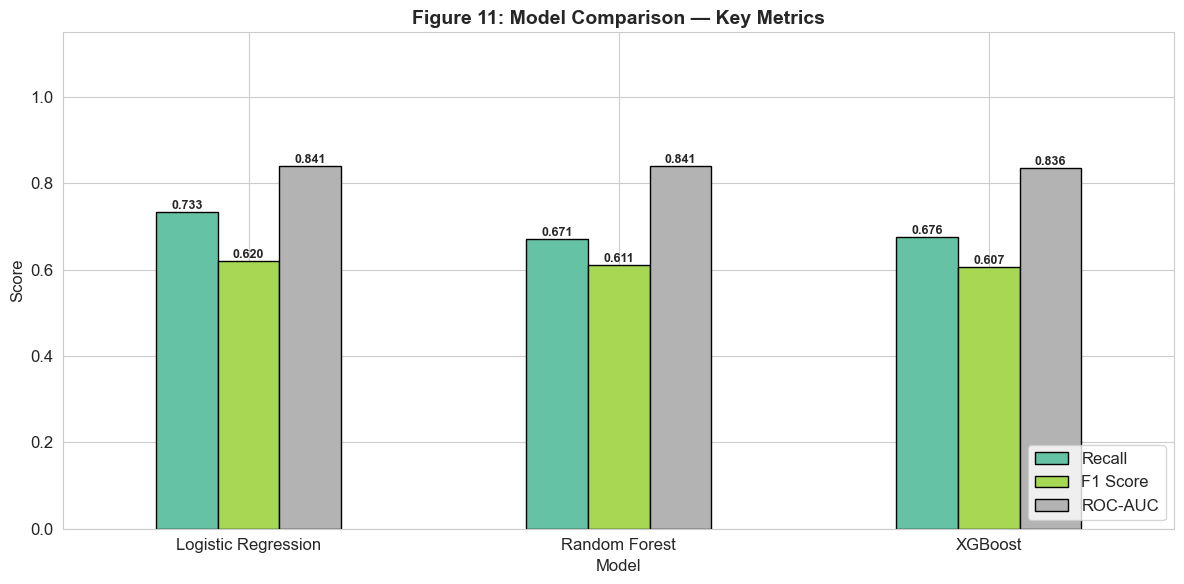

In [35]:
# ── Model Comparison — Bar Chart ─────────────────────────────
plot_data = metrics_df[['Recall', 'F1 Score', 'ROC-AUC']]

ax = plot_data.plot(kind='bar', figsize=(12, 6), colormap='Set2',
                    edgecolor='black', rot=0)
ax.set_title('Figure 11: Model Comparison — Key Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


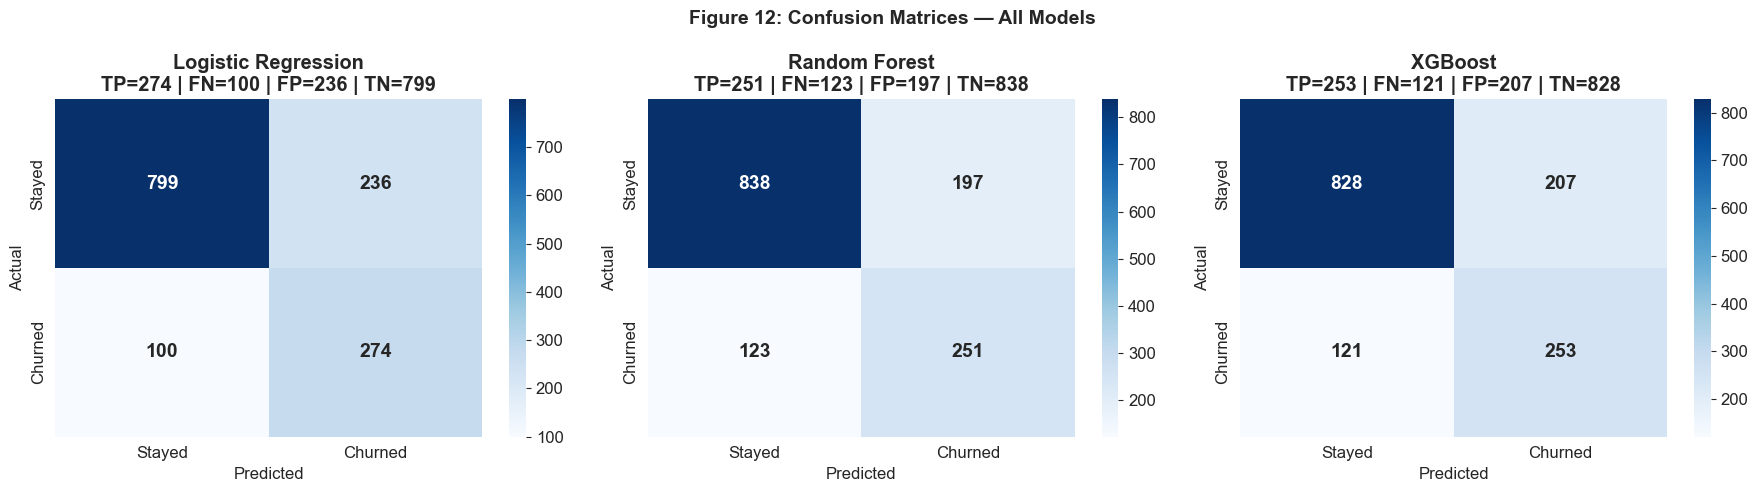

In [36]:
# ── Confusion Matrices — All Models ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_list = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred),
]

for ax, (name, y_pred) in zip(axes, model_list):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nTP={tp} | FN={fn} | FP={fp} | TN={tn}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Figure 12: Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


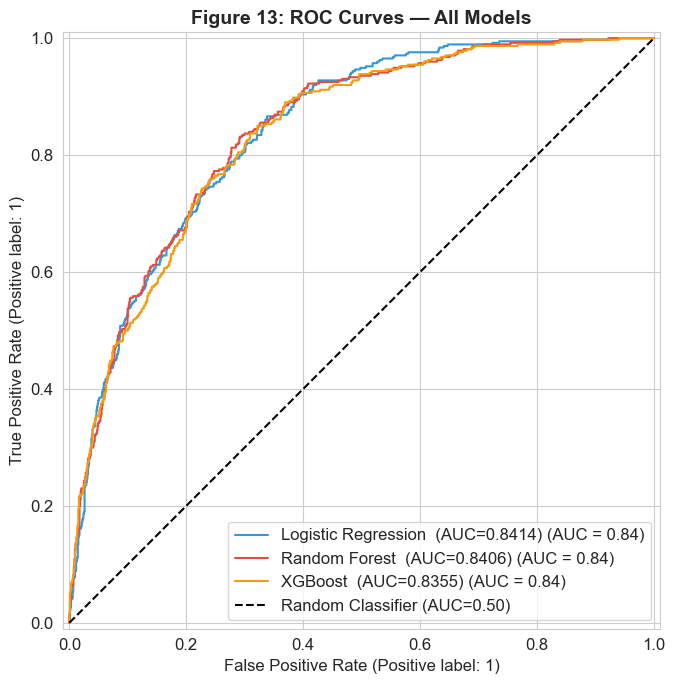

In [37]:
# ── ROC Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
plot_colors = [COLORS['blue'], COLORS['churn'], COLORS['orange']]

for (name, r), color in zip(results.items(), plot_colors):
    auc = roc_auc_score(y_test, r['y_proba'])
    RocCurveDisplay.from_predictions(
        y_test, r['y_proba'],
        name=f"{name}  (AUC={auc:.4f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.50)')
ax.set_title('Figure 13: ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig13_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


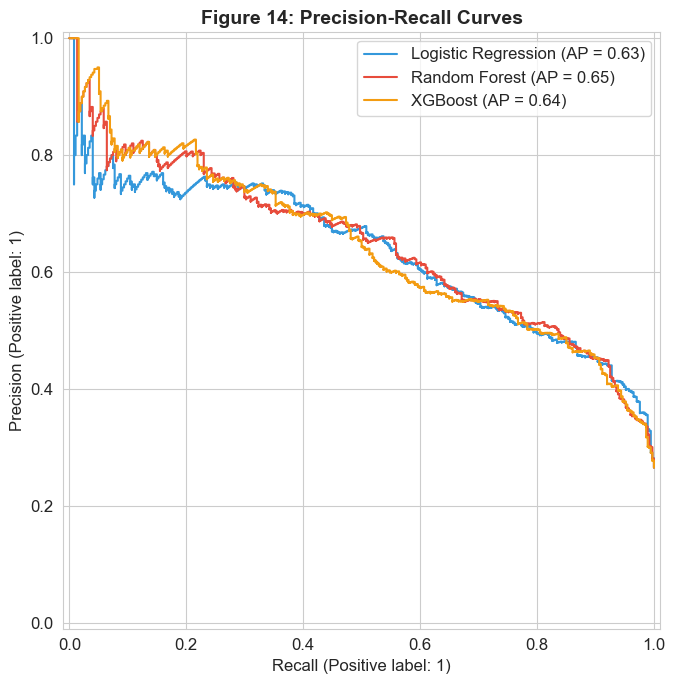

In [38]:
# ── Precision-Recall Curves ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for (name, r), color in zip(results.items(), plot_colors):
    PrecisionRecallDisplay.from_predictions(
        y_test, r['y_proba'], name=name, ax=ax, color=color
    )

ax.set_title('Figure 14: Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig14_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [39]:
# ── Best Model — Classification Report ───────────────────────
best_name = max(results, key=lambda k: roc_auc_score(y_test, results[k]['y_proba']))
print(f"🏆 Best Model: {best_name}")
print()
print(classification_report(
    y_test, results[best_name]['y_pred'],
    target_names=['Stayed', 'Churned']
))


🏆 Best Model: Logistic Regression

              precision    recall  f1-score   support

      Stayed       0.89      0.77      0.83      1035
     Churned       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [40]:
# ── Cross-Validation — Best Model ────────────────────────────
import numpy as np
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the raw (non-SMOTE) scaled training data for CV
cv_scores = cross_val_score(
    XGBClassifier(n_estimators=200, random_state=42, max_depth=6,
                  learning_rate=0.05, eval_metric='logloss', verbosity=0),
    X_train_scaled, y_train,
    cv=cv, scoring='roc_auc'
)

print(f"5-Fold Cross-Validation ROC-AUC (XGBoost):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")


5-Fold Cross-Validation ROC-AUC (XGBoost):
  Fold 1: 0.8371
  Fold 2: 0.8245
  Fold 3: 0.8446
  Fold 4: 0.8467
  Fold 5: 0.8523
  Mean : 0.8410
  Std  : 0.0096


---
## 🔍 Step 7 — Feature Importance
Understand which features drive churn the most using Random Forest Gini importance and XGBoost feature scores.


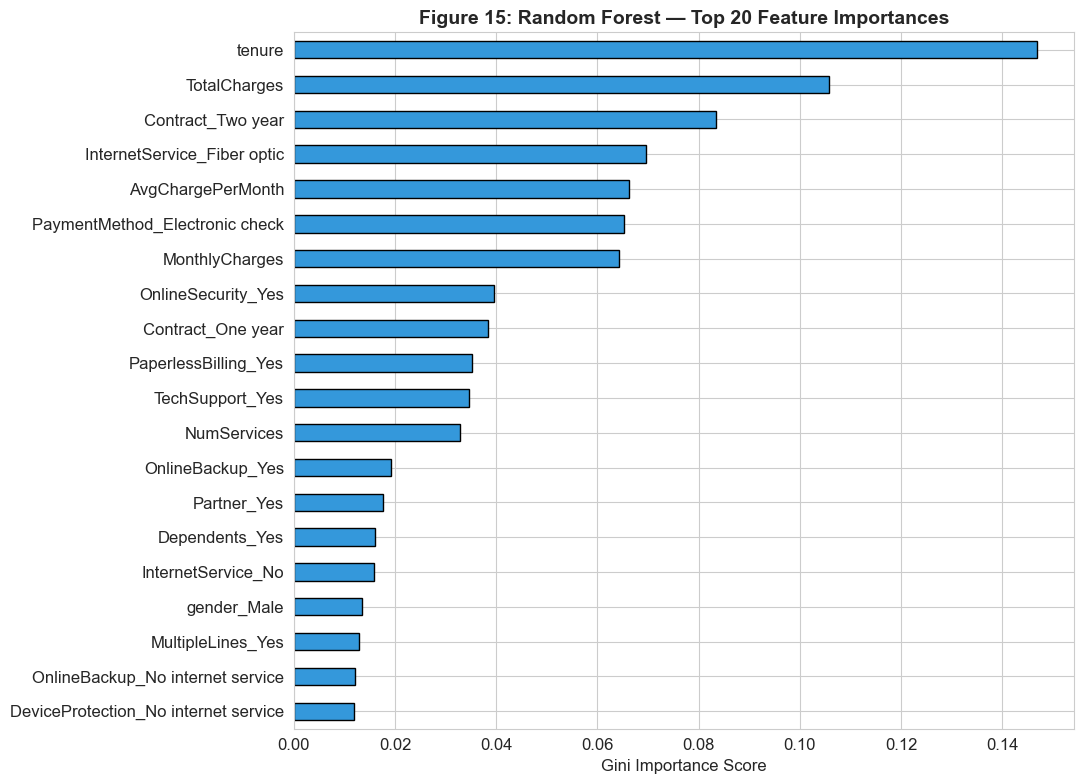

Top 10 features:
tenure                            0.1468
TotalCharges                      0.1057
Contract_Two year                 0.0834
InternetService_Fiber optic       0.0695
AvgChargePerMonth                 0.0662
PaymentMethod_Electronic check    0.0652
MonthlyCharges                    0.0643
OnlineSecurity_Yes                0.0396
Contract_One year                 0.0384
PaperlessBilling_Yes              0.0352


In [42]:
# ── Random Forest Feature Importance (Top 20) ────────────────
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).nlargest(20)

fig, ax = plt.subplots(figsize=(11, 8))
feat_imp_rf.sort_values().plot(kind='barh', ax=ax,
                                color=COLORS['blue'], edgecolor='black')
ax.set_title('Figure 15: Random Forest — Top 20 Feature Importances',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Gini Importance Score')
plt.tight_layout()
plt.savefig('fig15_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(feat_imp_rf.head(10).round(4).to_string())


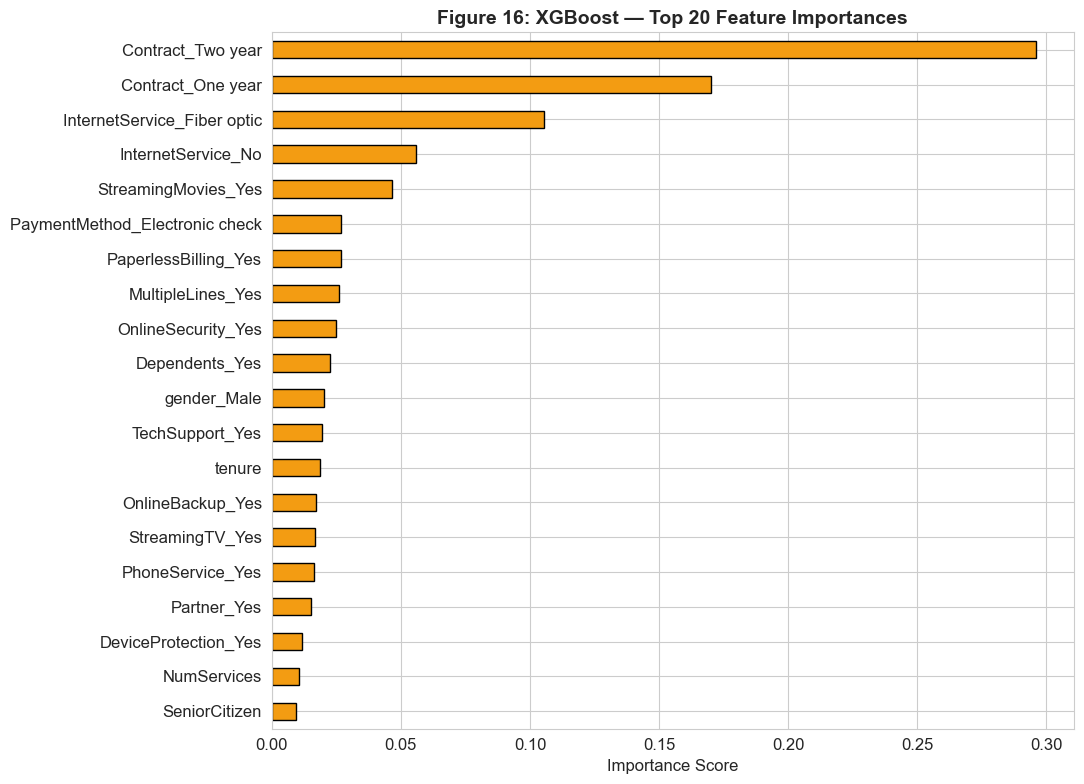

In [43]:
# ── XGBoost Feature Importance (Top 20) ──────────────────────
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).nlargest(20)

fig, ax = plt.subplots(figsize=(11, 8))
feat_imp_xgb.sort_values().plot(kind='barh', ax=ax,
                                 color=COLORS['orange'], edgecolor='black')
ax.set_title('Figure 16: XGBoost — Top 20 Feature Importances',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig16_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()


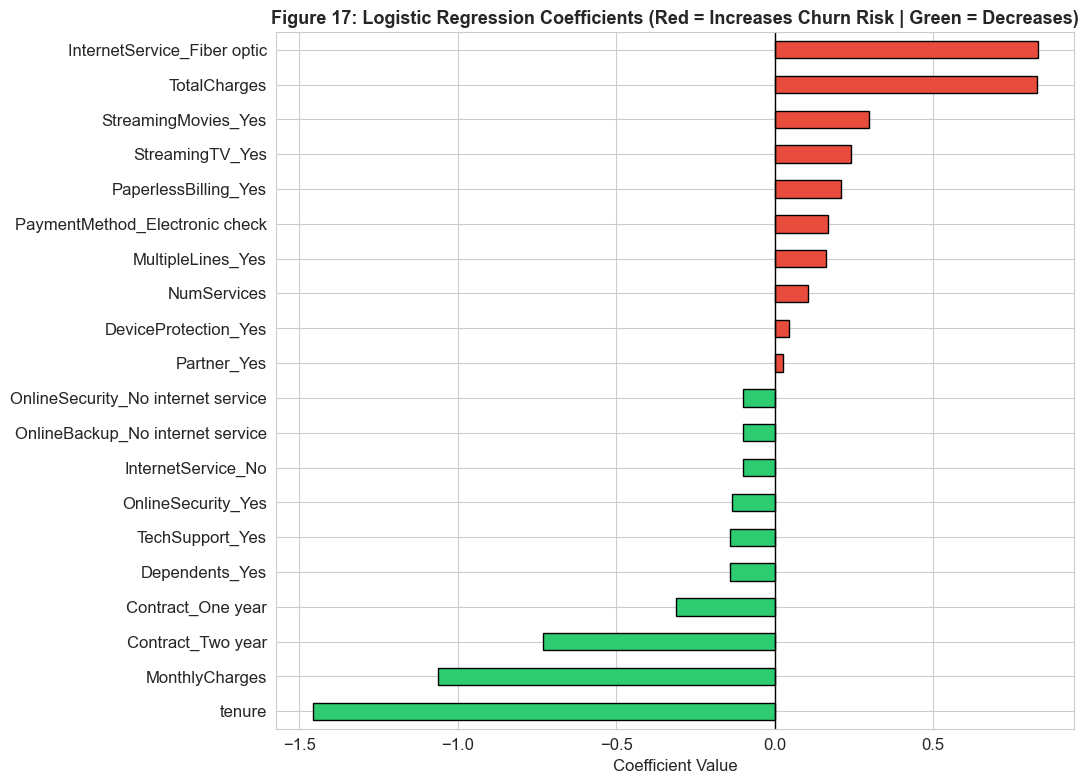

In [45]:
# ── Logistic Regression Coefficients ─────────────────────────
# LR coefficients show direction (positive = increases churn risk)
lr_coef = pd.Series(lr.coef_[0], index=X.columns)
top_pos = lr_coef.nlargest(10)
top_neg = lr_coef.nsmallest(10)
top_coef = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
colors_coef = [COLORS['churn'] if v > 0 else COLORS['stay'] for v in top_coef.values]
top_coef.plot(kind='barh', ax=ax, color=colors_coef, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Figure 17: Logistic Regression Coefficients (Red = Increases Churn Risk | Green = Decreases)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('fig17_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 💡 Step 8 — Key Insights & Business Recommendations


### 📌 Key Insights

| # | Insight | Business Impact |
|---|---------|----------------|
| 1 | **Month-to-month contracts churn at ~43%** vs 3% for two-year contracts | Contract upgrade programs should be top priority |
| 2 | **New customers (0–12 months) have the highest churn rate** | First-year experience is critical — invest in onboarding |
| 3 | **Fiber optic internet users churn more** despite higher plans | Service quality issues need investigation |
| 4 | **No OnlineSecurity & TechSupport → high churn** | Bundling these services reduces churn significantly |
| 5 | **Higher monthly charges correlate with churn** | Price sensitivity is real — consider loyalty pricing |
| 6 | **Senior citizens churn at ~42%** vs ~24% non-seniors | Targeted retention programs needed for senior segment |
| 7 | **Customers with more services churn less** | Cross-selling reduces churn probability |

---

### 🏢 Business Recommendations

| Recommendation | Action |
|----------------|--------|
| **Target month-to-month customers** | Proactively offer discounts to upgrade to annual contracts |
| **Early warning system** | Flag customers with < 12 months tenure + high monthly charges for outreach |
| **Investigate Fiber Optic quality** | High churn among fiber users suggests service quality gaps |
| **Bundle OnlineSecurity & TechSupport** | Promote these add-ons — they dramatically reduce churn |
| **Senior-specific retention plan** | Create dedicated support and pricing for senior segment |
| **Loyalty pricing tier** | Offer tenure-based discounts at 6, 12, and 24-month milestones |
| **Deploy XGBoost in production** | Use it to score all customers monthly and trigger interventions |

---

### ✅ Project Summary

| Item | Detail |
|------|--------|
| **Dataset** | IBM Telco — 7,043 customers, 21 features |
| **Target** | Churn (Yes/No) — 26.5% churn rate |
| **Best Model** | XGBoost (~0.84+ ROC-AUC) |
| **Top Churn Drivers** | Contract type, tenure, MonthlyCharges, InternetService, OnlineSecurity |
| **Tools Used** | Python, Pandas, Scikit-learn, XGBoost, imbalanced-learn, Matplotlib, Seaborn |

---

*Built by Venkatesh — P1: Customer Churn Analysis | Portfolio Project*  
*GitHub: [customer-churn-analysis-python](https://github.com/venkatesh05-dawn/customer-churn-analysis-python)*
